In [27]:
import pandas as pd
import sys
from sklearn.linear_model import LogisticRegression
from sklearn.linear_model import SGDClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import GradientBoostingClassifier

from sklearn.model_selection import GridSearchCV
from sklearn.model_selection import RandomizedSearchCV

sys.path.insert(0, "../src")
from data_cleaner import DataCleaner
from encoder import Encoder
from sampler import oversample
from evaluator import evaluate_model, interpret_decision_tree
from run import run


In [2]:
pd.set_option('display.max_columns', None) # show full dataframe

In [3]:
# import data
train_val = pd.read_csv("../data/training_set_values.csv")
train_label = pd.read_csv("../data/training_set_labels.csv")


# merge train and target data
train_data = pd.merge(train_val, train_label, on="id")

In [4]:
train_data

,id,amount_tsh,date_recorded,funder,gps_height,installer,longitude,latitude,wpt_name,num_private,basin,subvillage,region,region_code,district_code,lga,ward,population,public_meeting,recorded_by,scheme_management,scheme_name,permit,construction_year,extraction_type,extraction_type_group,extraction_type_class,management,management_group,payment,payment_type,water_quality,quality_group,quantity,quantity_group,source,source_type,source_class,waterpoint_type,waterpoint_type_group,status_group
0,69572,6000.0,14/03/2011,Roman,1390,Roman,34.938093,-9.856322,none,0,Lake Nyasa,Mnyusi B,Iringa,11,5,Ludewa,Mundindi,109,True,GeoData Consultants Ltd,VWC,Roman,False,1999,gravity,gravity,gravity,vwc,user-group,pay annually,annually,soft,good,enough,enough,spring,spring,groundwater,communal standpipe,communal standpipe,functional
1,8776,0.0,06/03/2013,Grumeti,1399,GRUMETI,34.698766,-2.147466,Zahanati,0,Lake Victoria,Nyamara,Mara,20,2,Serengeti,Natta,280,NaN,GeoData Consultants Ltd,Other,NaN,True,2010,gravity,gravity,gravity,wug,user-group,never pay,never pay,soft,good,insufficient,insufficient,rainwater harvesting,rainwater harvesting,surface,communal standpipe,communal standpipe,functional
2,34310,25.0,25/02/2013,Lottery Club,686,World vision,37.460664,-3.821329,Kwa Mahundi,0,Pangani,Majengo,Manyara,21,4,Simanjiro,Ngorika,250,True,GeoData Consultants Ltd,VWC,Nyumba ya mungu pipe scheme,True,2009,gravity,gravity,gravity,vwc,user-group,pay per bucket,per bucket,soft,good,enough,enough,dam,dam,surface,communal standpipe multiple,communal standpipe,functional
3,67743,0.0,28/01/2013,Unicef,263,UNICEF,38.486161,-11.155298,Zahanati Ya Nanyumbu,0,Ruvuma / Southern Coast,Mahakamani,Mtwara,90,63,Nanyumbu,Nanyumbu,58,True,GeoData Consultants Ltd,VWC,NaN,True,1986,submersible,submersible,submersible,vwc,user-group,never pay,never pay,soft,good,dry,dry,machine dbh,borehole,groundwater,communal standpipe multiple,communal standpipe,non functional
4,19728,0.0,13/07/2011,Action In A,0,Artisan,31.130847,-1.825359,Shuleni,0,Lake Victoria,Kyanyamisa,Kagera,18,1,Karagwe,Nyakasimbi,0,True,GeoData Consultants Ltd,NaN,NaN,True,0,gravity,gravity,gravity,other,other,never pay,never pay,soft,good,seasonal,seasonal,rainwater harvesting,rainwater harvesting,surface,communal standpipe,communal standpipe,functional
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
59395,60739,10.0,03/05/2013,Germany Republi,1210,CES,37.169807,-3.253847,Area Three Namba 27,0,Pangani,Kiduruni,Kilimanjaro,3,5,Hai,Masama Magharibi,125,True,GeoData Consultants Ltd,Water Board,Losaa Kia water supply,True,1999,gravity,gravity,gravity,water board,user-group,pay per bucket,per bucket,soft,good,enough,enough,spring,spring,groundwater,communal standpipe,communal standpipe,functional
59396,27263,4700.0,07/05/2011,Cefa-njombe,1212,Cefa,35.249991,-9.070629,Kwa Yahona Kuvala,0,Rufiji,Igumbilo,Iringa,11,4,Njombe,Ikondo,56,True,GeoData Consultants Ltd,VWC,Ikondo electrical water sch,True,1996,gravity,gravity,gravity,vwc,user-group,pay annually,annually,soft,good,enough,enough,river,river/lake,surface,communal standpipe,communal standpipe,functional
59397,37057,0.0,11/04/2011,NaN,0,NaN,34.017087,-8.750434,Mashine,0,Rufiji,Madungulu,Mbeya,12,7,Mbarali,Chimala,0,True,GeoData Consultants Ltd,VWC,NaN,False,0,swn 80,swn 80,handpump,vwc,user-group,pay monthly,monthly,fluoride,fluoride,enough,enough,machine dbh,borehole,groundwater,hand pump,hand pump,functional
59398,31282,0.0,08/03/2011,Malec,0,Musa,35.861315,-6.378573,Mshoro,0,Rufiji,Mwinyi,Dodoma,1,4,Chamwino,Mvumi Makulu,0,True,GeoData Consultants Ltd,VWC,NaN,True,0,nira/tanira,nira/tanira,handpump,vwc,user-group,never pay,never pay,soft,good,insufficient,insufficient,shallow well,shallow well,groundwater,hand pump,hand pump,functional


In [5]:
clean = DataCleaner()

cleaned_df = clean.preprocess(train_data)

c:\Users\Owner\Python\Data_Circle\notebooks\../src\data_cleaner.py:22: UserWarning: Parsing dates in %d/%m/%Y format when dayfirst=False (the default) was specified. Pass `dayfirst=True` or specify a format to silence this warning.
  dataframe["date_recorded"] = pd.to_datetime(dataframe['date_recorded'])
2025-11-19 16:26:53,103 - INFO - Removed -9 invalid rows (negative pump_age). Remaining rows: 59391
2025-11-19 16:26:53,109 - INFO - Data cleaning completed.


In [6]:
cleaned_df

,quantity_group,region,payment_type,extraction_type_class,management,quality_group,pump_age,status_group
0,enough,Iringa,annually,gravity,vwc,good,12.000000,functional
1,insufficient,Mara,never pay,gravity,wug,good,3.000000,functional
2,enough,Manyara,per bucket,gravity,vwc,good,4.000000,functional
3,dry,Mtwara,never pay,submersible,vwc,good,27.000000,non functional
4,seasonal,Kagera,never pay,gravity,other,good,14.185314,functional
...,...,...,...,...,...,...,...,...
59386,enough,Kilimanjaro,per bucket,gravity,water board,good,14.000000,functional
59387,enough,Iringa,annually,gravity,vwc,good,15.000000,functional
59388,enough,Mbeya,monthly,handpump,vwc,fluoride,14.185314,functional
59389,insufficient,Dodoma,never pay,handpump,vwc,good,14.185314,functional


In [7]:
encode = Encoder()

encoded_df = encode.encode_categorcial_value(cleaned_df)
encoded_df

,pump_age,quantity_group_dry,quantity_group_enough,quantity_group_insufficient,quantity_group_seasonal,quantity_group_unknown,region_Arusha,region_Dar es Salaam,region_Dodoma,region_Iringa,region_Kagera,region_Kigoma,region_Kilimanjaro,region_Lindi,region_Manyara,region_Mara,region_Mbeya,region_Morogoro,region_Mtwara,region_Mwanza,region_Pwani,region_Rukwa,region_Ruvuma,region_Shinyanga,region_Singida,region_Tabora,region_Tanga,payment_type_annually,payment_type_monthly,payment_type_never pay,payment_type_on failure,payment_type_other,payment_type_per bucket,payment_type_unknown,extraction_type_class_gravity,extraction_type_class_handpump,extraction_type_class_motorpump,extraction_type_class_other,extraction_type_class_rope pump,extraction_type_class_submersible,extraction_type_class_wind-powered,management_company,management_other,management_other - school,management_parastatal,management_private operator,management_trust,management_unknown,management_vwc,management_water authority,management_water board,management_wua,management_wug,quality_group_colored,quality_group_fluoride,quality_group_good,quality_group_milky,quality_group_salty,quality_group_unknown,status_group
0,12.000000,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,2
1,3.000000,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,2
2,4.000000,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,2
3,27.000000,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0
4,14.185314,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
59386,14.000000,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,2
59387,15.000000,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,2
59388,14.185314,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,2
59389,14.185314,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,2


### Baseline model comparison

Oversample with basic oversampling
Before Oversampling -> After Oversampling
functional:  32255 -> 32255
non functional: 22819 -> 32255
functional needs repair: 4317 -> 32255
ITERATION 1 / 5
accuracy_score:  0.6746757608639488
ITERATION 2 / 5
accuracy_score:  0.6738490156564874
ITERATION 3 / 5
accuracy_score:  0.6636697152896192
ITERATION 4 / 5
accuracy_score:  0.7586420709967447
ITERATION 5 / 5
accuracy_score:  0.6505968066966362
                         precision    recall  f1-score   support

         non functional       0.79      0.72      0.75     32255
functional needs repair       0.64      0.72      0.68     32255
             functional       0.63      0.61      0.62     32255

               accuracy                           0.68     96765
              macro avg       0.69      0.68      0.68     96765
           weighted avg       0.69      0.68      0.68     96765



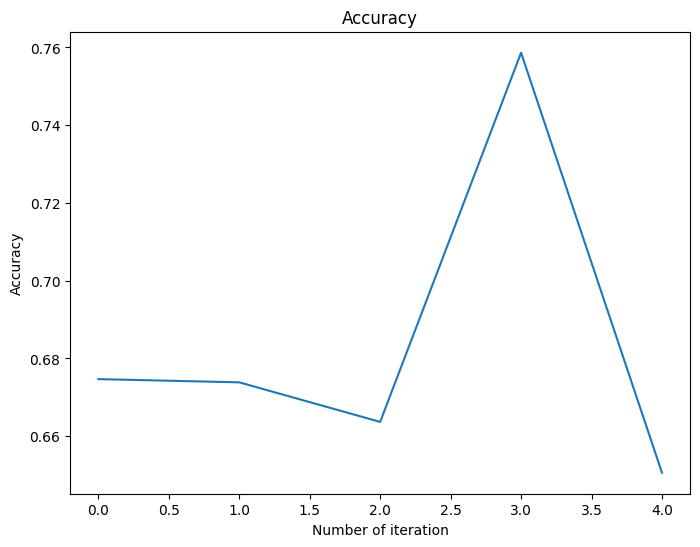

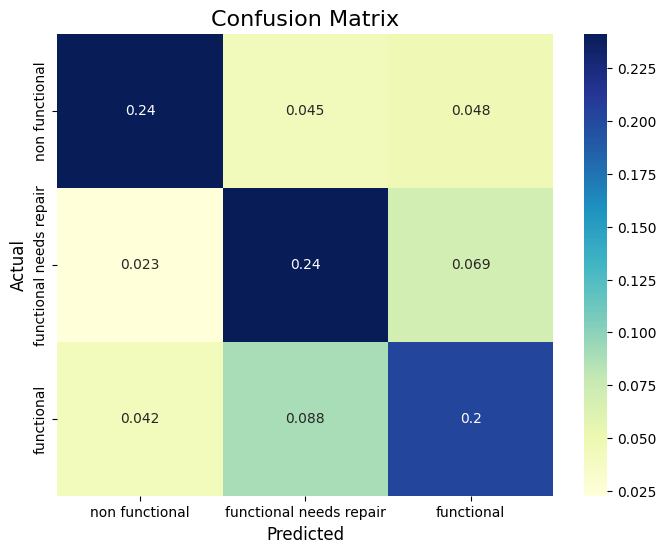

In [28]:
classifiers = GradientBoostingClassifier()

y_test_all, y_pred_all, accuracy_all, clf = run(data=encoded_df,
                                            is_oversample=True,
                                            classifier=classifier,
                                            k_fold_split=5,
                                            method="basic")

evaluate_model(y_test_all=y_test_all,
               y_pred_all=y_pred_all,
               accuracy_all=accuracy_all)

Oversample with basic oversampling
Before Oversampling -> After Oversampling
functional:  32255 -> 32255
non functional: 22819 -> 32255
functional needs repair: 4317 -> 32255
ITERATION 1 / 5
accuracy_score:  0.6755541776468764
ITERATION 2 / 5
accuracy_score:  0.6758642070996744
ITERATION 3 / 5
accuracy_score:  0.6649615046762776
ITERATION 4 / 5
accuracy_score:  0.7602955614116674
ITERATION 5 / 5
accuracy_score:  0.6520436108096936
                         precision    recall  f1-score   support

         non functional       0.78      0.72      0.75     32255
functional needs repair       0.65      0.72      0.68     32255
             functional       0.63      0.61      0.62     32255

               accuracy                           0.69     96765
              macro avg       0.69      0.69      0.69     96765
           weighted avg       0.69      0.69      0.69     96765



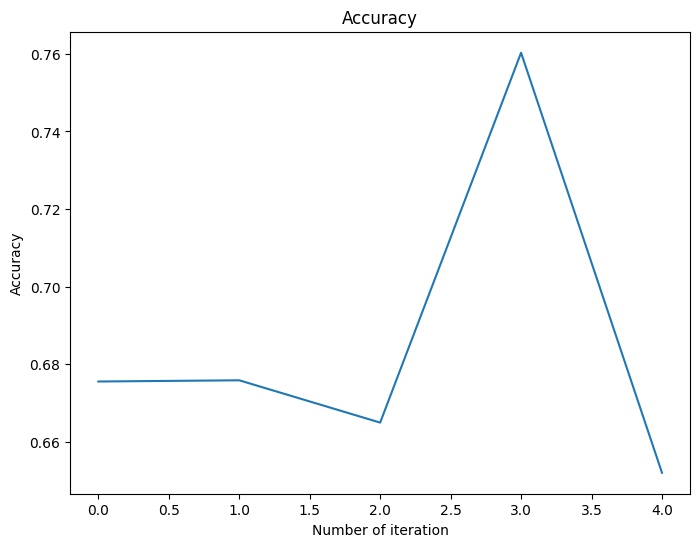

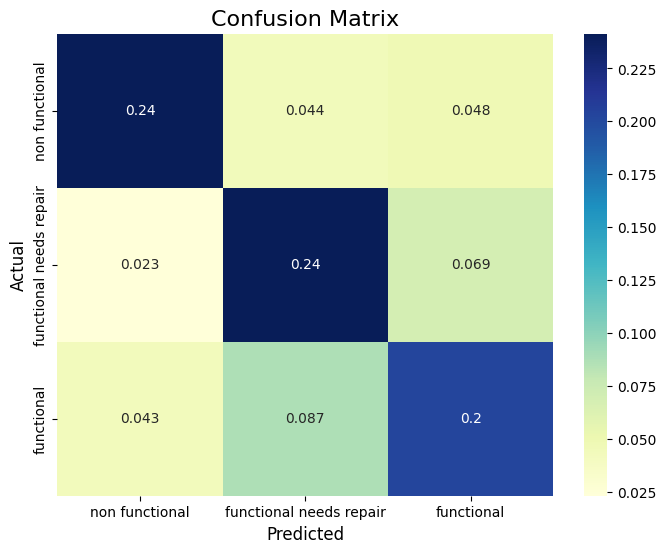

In [23]:
classifier = RandomForestClassifier()

y_test_all, y_pred_all, accuracy_all, clf = run(data=encoded_df,
                                            is_oversample=True,
                                            classifier=classifier,
                                            k_fold_split=5,
                                            method="basic")

evaluate_model(y_test_all=y_test_all,
               y_pred_all=y_pred_all,
               accuracy_all=accuracy_all)

Oversample with basic oversampling
Before Oversampling -> After Oversampling
functional:  32255 -> 32255
non functional: 22819 -> 32255
functional needs repair: 4317 -> 32255
ITERATION 1 / 5
accuracy_score:  0.666408308789335
ITERATION 2 / 5
accuracy_score:  0.6646514752234796
ITERATION 3 / 5
accuracy_score:  0.6542138169792797
ITERATION 4 / 5
accuracy_score:  0.7686663566372138
ITERATION 5 / 5
accuracy_score:  0.6615511806954995
                         precision    recall  f1-score   support

         non functional       0.77      0.73      0.75     32255
functional needs repair       0.64      0.73      0.68     32255
             functional       0.64      0.59      0.61     32255

               accuracy                           0.68     96765
              macro avg       0.69      0.68      0.68     96765
           weighted avg       0.69      0.68      0.68     96765



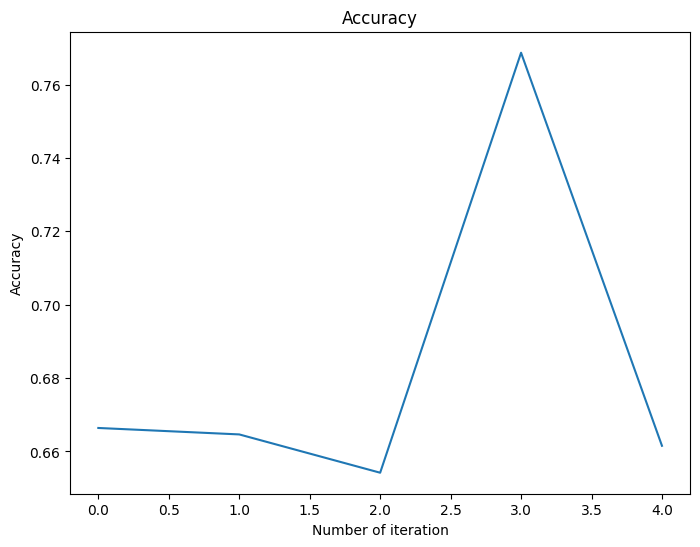

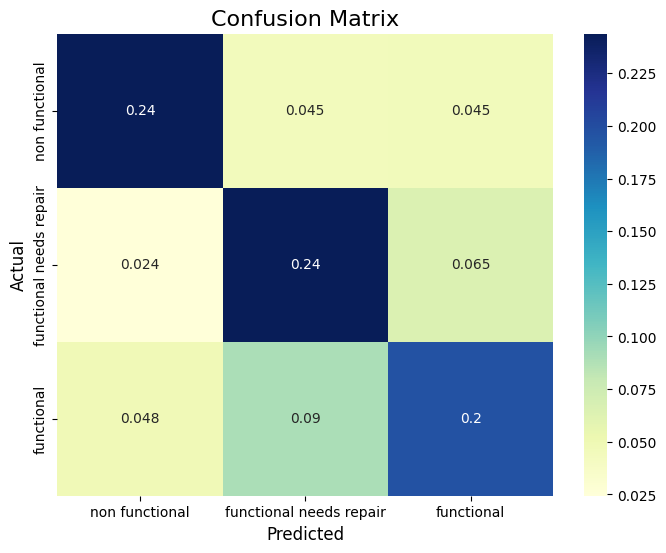

In [18]:

### Decision tree
# Source: https://www.datacamp.com/tutorial/decision-tree-classification-python
classifier = DecisionTreeClassifier(max_depth=50)

y_test_all, y_pred_all, accuracy_all, clf = run(data=encoded_df,
                                            is_oversample=True,
                                            classifier=classifier,
                                            k_fold_split=5,
                                            method="basic")

evaluate_model(y_test_all=y_test_all,
               y_pred_all=y_pred_all,
               accuracy_all=accuracy_all)

Oversample with basic oversampling
Before Oversampling -> After Oversampling
functional:  32255 -> 32255
non functional: 22819 -> 32255
functional needs repair: 4317 -> 32255
ITERATION 1 / 5


c:\Users\Owner\Python\Data_Circle\env\Lib\site-packages\sklearn\linear_model\_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 100 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=100).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


accuracy_score:  0.5451867927453108
ITERATION 2 / 5


c:\Users\Owner\Python\Data_Circle\env\Lib\site-packages\sklearn\linear_model\_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 100 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=100).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


accuracy_score:  0.5391928899912158
ITERATION 3 / 5


...

accuracy_score:  0.5351625071048416
ITERATION 4 / 5


c:\Users\Owner\Python\Data_Circle\env\Lib\site-packages\sklearn\linear_model\_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 100 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=100).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


accuracy_score:  0.5538676174236552
ITERATION 5 / 5


c:\Users\Owner\Python\Data_Circle\env\Lib\site-packages\sklearn\linear_model\_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 100 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=100).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


accuracy_score:  0.21324859194956855
                         precision    recall  f1-score   support

         non functional       0.66      0.57      0.61     32255
functional needs repair       0.38      0.37      0.37     32255
             functional       0.43      0.49      0.46     32255

               accuracy                           0.48     96765
              macro avg       0.49      0.48      0.48     96765
           weighted avg       0.49      0.48      0.48     96765



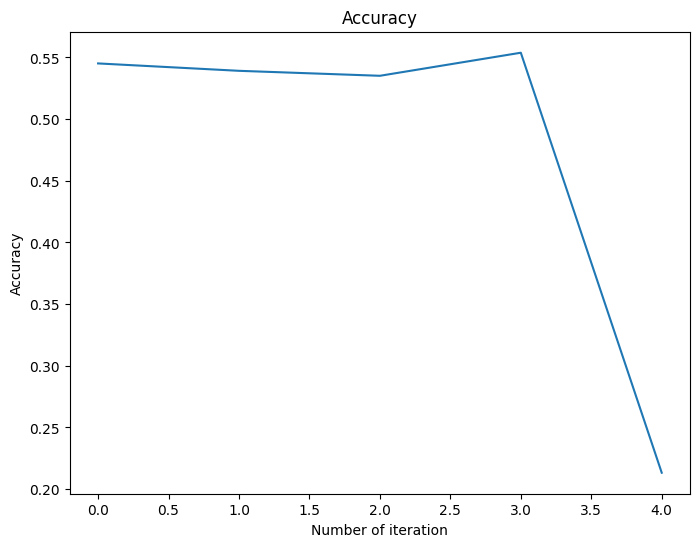

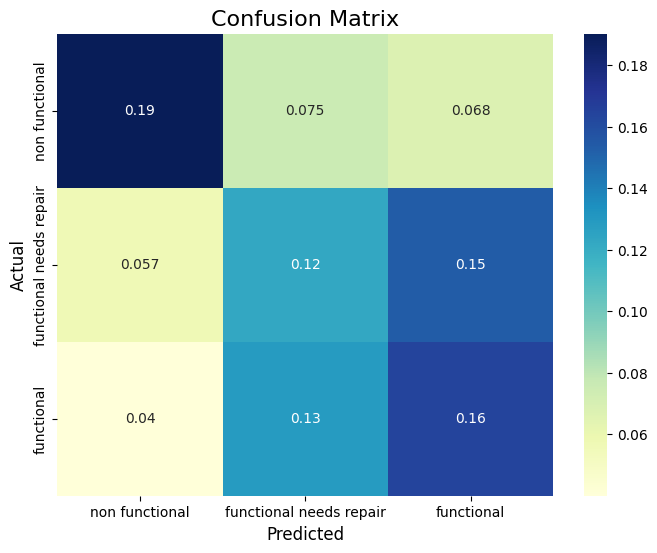

In [29]:
### Softmax regression
# classifier = LogisticRegression(C=1e5, solver='newton-cg')
classifier = LogisticRegression()



y_test_all, y_pred_all, accuracy_all, clf = run(data=encoded_df,
                                            is_oversample=True,
                                            classifier=classifier,
                                            k_fold_split=5,
                                            method="basic")

evaluate_model(y_test_all=y_test_all,
               y_pred_all=y_pred_all,
               accuracy_all=accuracy_all)

Oversample with basic oversampling
Before Oversampling -> After Oversampling
functional:  32255 -> 32255
non functional: 22819 -> 32255
functional needs repair: 4317 -> 32255
ITERATION 1 / 5
accuracy_score:  0.4993541053066708
ITERATION 2 / 5
accuracy_score:  0.5874024699013073
ITERATION 3 / 5
accuracy_score:  0.4270655712292668
ITERATION 4 / 5
accuracy_score:  0.5311837957939337
ITERATION 5 / 5
accuracy_score:  0.04924301141941818
                         precision    recall  f1-score   support

         non functional       0.57      0.62      0.59     32255
functional needs repair       0.23      0.19      0.21     32255
             functional       0.41      0.45      0.43     32255

               accuracy                           0.42     96765
              macro avg       0.40      0.42      0.41     96765
           weighted avg       0.40      0.42      0.41     96765



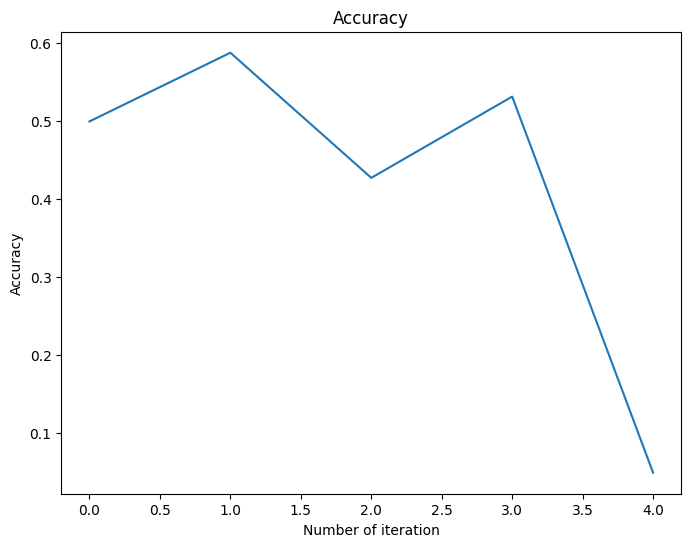

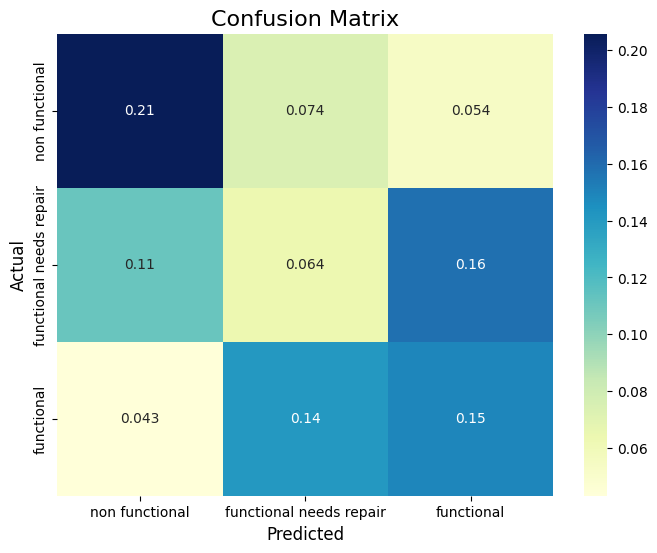

In [30]:
### linear classifier with SGD
# classifier = SGDClassifier(max_iter=1000, tol=1e-3)
classifier = SGDClassifier()




y_test_all, y_pred_all, accuracy_all, clf = run(data=encoded_df,
                                            is_oversample=True,
                                            classifier=classifier,
                                            k_fold_split=5,
                                            method="basic")

evaluate_model(y_test_all=y_test_all,
               y_pred_all=y_pred_all,
               accuracy_all=accuracy_all)

### Summary of Baseline model comparison:
**Tree-based model**  
- XGboost classifier: Acc 0.68 
- RandomForest classifier: Acc 0.69
- DecisionTree: Acc 0.68

Precision of "non functional" is the highest, followed by order of "needs repair" and "functional.

**Linear model**  
- softmax regression : Acc 0.48
- SGD classifier: Acc 0.42

Precision of "non functional" is the highest, followed by order of "functional" and "needs repair".

### Comparison of oversampling

1. Simple oversampling

Oversample with basic oversampling
Before Oversampling -> After Oversampling
functional:  32255 -> 32255
non functional: 22819 -> 32255
functional needs repair: 4317 -> 32255
ITERATION 1 / 5
accuracy_score:  0.6759158786751408
ITERATION 2 / 5
accuracy_score:  0.6759158786751408
ITERATION 3 / 5
accuracy_score:  0.6645998036480132
ITERATION 4 / 5
accuracy_score:  0.7590554436004754
ITERATION 5 / 5
accuracy_score:  0.6559706505451351
                         precision    recall  f1-score   support

         non functional       0.79      0.72      0.75     32255
functional needs repair       0.65      0.73      0.68     32255
             functional       0.63      0.61      0.62     32255

               accuracy                           0.69     96765
              macro avg       0.69      0.69      0.69     96765
           weighted avg       0.69      0.69      0.69     96765



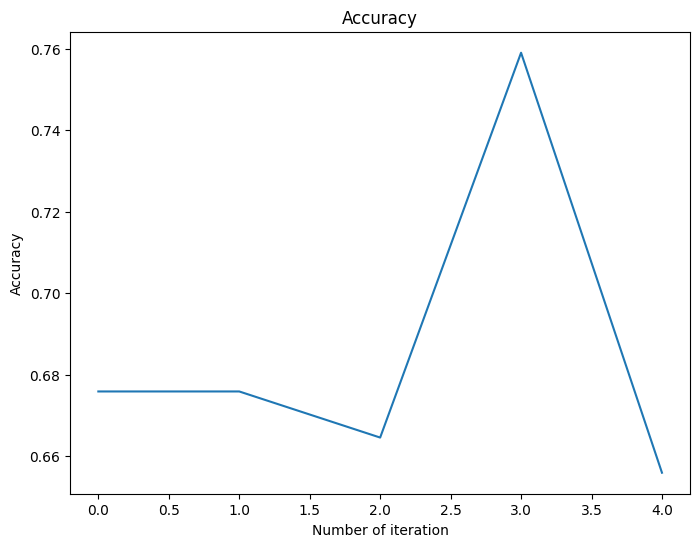

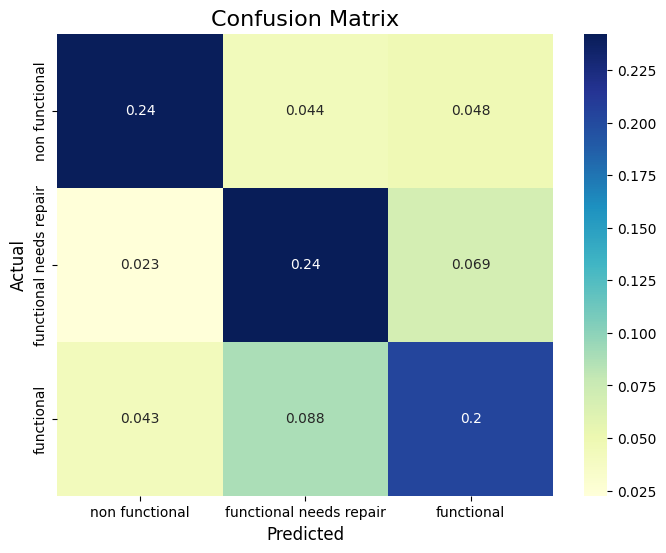

In [31]:
classifier = RandomForestClassifier()

y_test_all, y_pred_all, accuracy_all, clf = run(data=encoded_df,
                                            is_oversample=True,
                                            classifier=classifier,
                                            k_fold_split=5,
                                            method="basic")

evaluate_model(y_test_all=y_test_all,
               y_pred_all=y_pred_all,
               accuracy_all=accuracy_all)

2. Overrsampling usinf SMOTE

Oversample with SMOTE
Before Oversampling -> After Oversampling
functional:  32255 -> 32255
non functional: 22819 -> 32255
functional needs repair: 4317 -> 32255
ITERATION 1 / 5
accuracy_score:  0.7035601715496306
ITERATION 2 / 5
accuracy_score:  0.6998914896915207
ITERATION 3 / 5
accuracy_score:  0.6957577636542138
ITERATION 4 / 5
accuracy_score:  0.7680979693070842
ITERATION 5 / 5
accuracy_score:  0.7433989562341756
                         precision    recall  f1-score   support

         non functional       0.79      0.72      0.75     32255
functional needs repair       0.72      0.76      0.74     32255
             functional       0.67      0.69      0.68     32255

               accuracy                           0.72     96765
              macro avg       0.72      0.72      0.72     96765
           weighted avg       0.72      0.72      0.72     96765



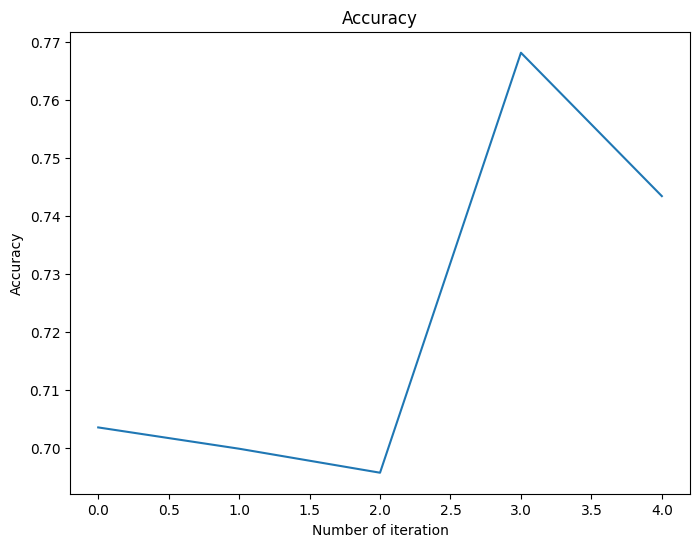

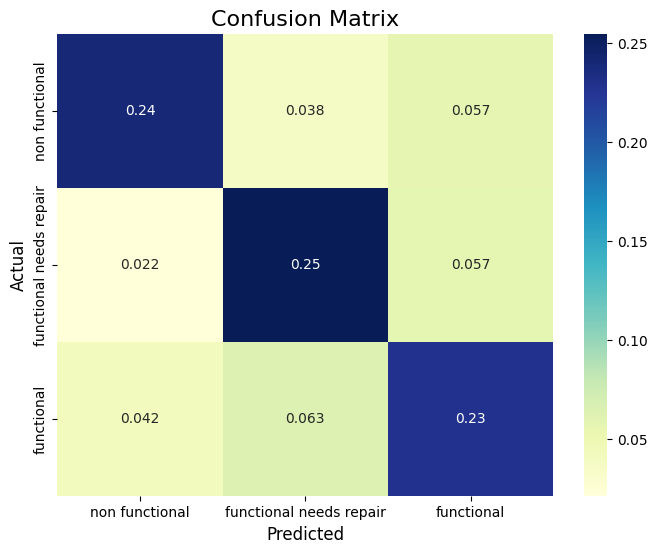

In [32]:
classifier = RandomForestClassifier()

y_test_all, y_pred_all, accuracy_all, clf = run(data=encoded_df,
                                            is_oversample=True,
                                            classifier=classifier,
                                            k_fold_split=5,
                                            method="smote")

evaluate_model(y_test_all=y_test_all,
               y_pred_all=y_pred_all,
               accuracy_all=accuracy_all)

3. Oversampling with ADASYN

Oversample with ADASYN
Before Oversampling -> After Oversampling
functional:  32255 -> 32255
non functional: 22819 -> 32486
functional needs repair: 4317 -> 31842
ITERATION 1 / 5
accuracy_score:  0.6908422632914013
ITERATION 2 / 5
accuracy_score:  0.6934306569343066
ITERATION 3 / 5
accuracy_score:  0.6895480664699487
ITERATION 4 / 5
accuracy_score:  0.5781217643404432
ITERATION 5 / 5
accuracy_score:  0.572375232967488
                         precision    recall  f1-score   support

         non functional       0.68      0.63      0.65     32486
functional needs repair       0.64      0.65      0.65     31842
             functional       0.62      0.65      0.63     32255

               accuracy                           0.64     96583
              macro avg       0.65      0.64      0.65     96583
           weighted avg       0.65      0.64      0.65     96583



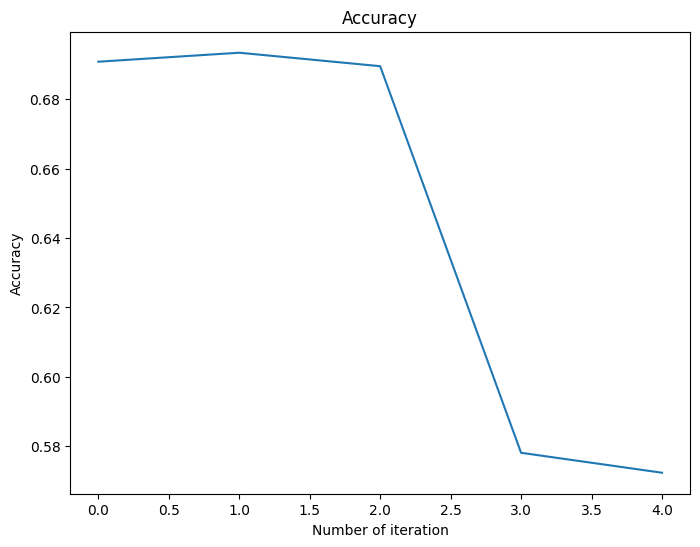

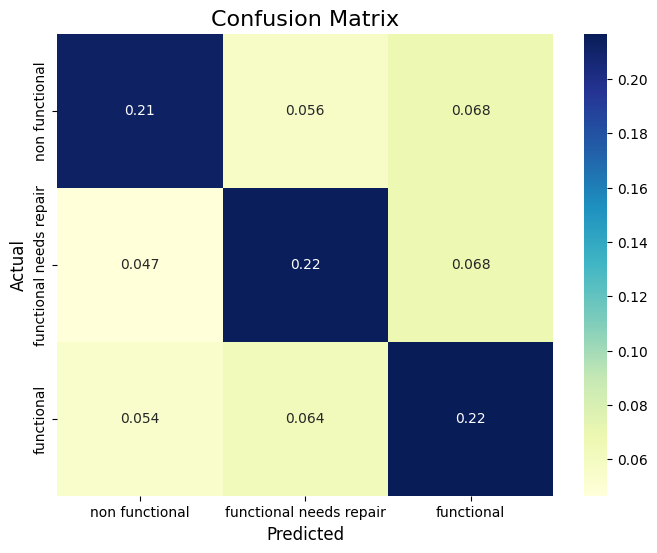

In [33]:
classifier = RandomForestClassifier()

y_test_all, y_pred_all, accuracy_all, clf = run(data=encoded_df,
                                            is_oversample=True,
                                            classifier=classifier,
                                            k_fold_split=5,
                                            method="adasyn")

evaluate_model(y_test_all=y_test_all,
               y_pred_all=y_pred_all,
               accuracy_all=accuracy_all)

4. Without oversampling

ITERATION 1 / 5
accuracy_score:  0.7653001094368213
ITERATION 2 / 5
accuracy_score:  0.7584610203738003
ITERATION 3 / 5
accuracy_score:  0.7610708873547736
ITERATION 4 / 5
accuracy_score:  0.7544199360161643
ITERATION 5 / 5
accuracy_score:  0.7641017006230005
                         precision    recall  f1-score   support

         non functional       0.79      0.72      0.75     22819
functional needs repair       0.44      0.19      0.27      4317
             functional       0.76      0.87      0.81     32255

               accuracy                           0.76     59391
              macro avg       0.66      0.59      0.61     59391
           weighted avg       0.75      0.76      0.75     59391



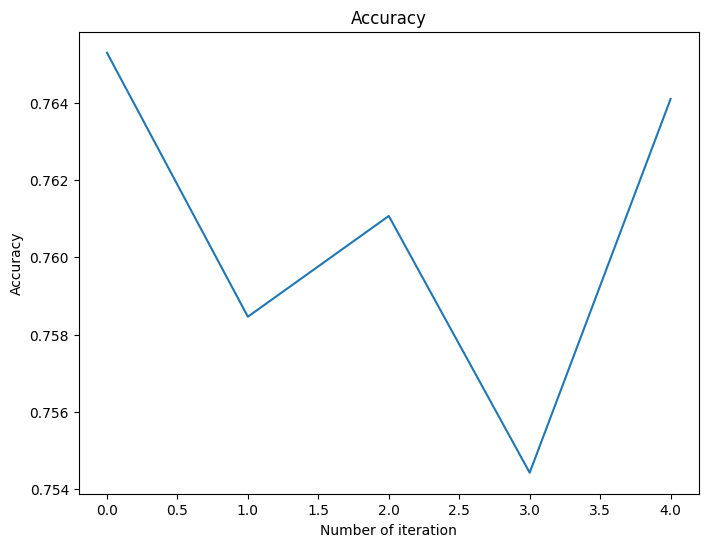

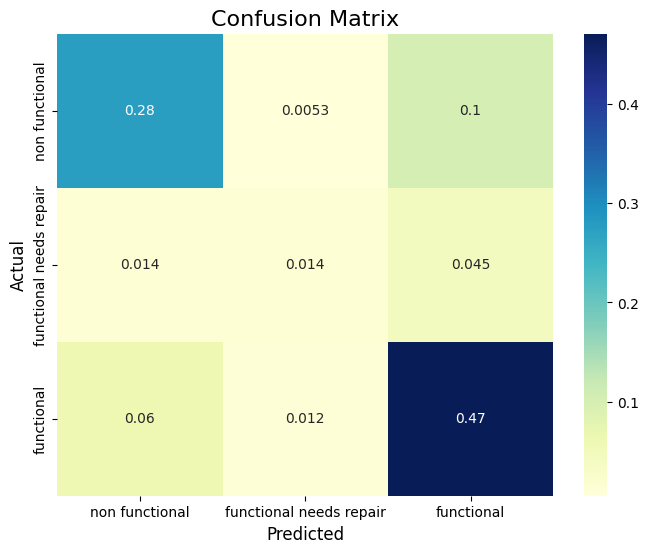

In [34]:
classifier = RandomForestClassifier()

y_test_all, y_pred_all, accuracy_all, clf = run(data=encoded_df,
                                            is_oversample=False,
                                            classifier=classifier,
                                            k_fold_split=5)

evaluate_model(y_test_all=y_test_all,
               y_pred_all=y_pred_all,
               accuracy_all=accuracy_all)

**Summary of experiemnt on class imbalance**  
- Oversampling "need to reprie" class significantly improved model performance (F1 score 27% -> 60-70%)
- SMOTE slightly overperformed other sampling method. Maybe tree-based models go with SMOTE the best